# Статистический анализ данных. Исследование популярного сервиса аренды самокатов GoFast

Передали данные о некоторых пользователях из нескольких городов, а также об их поездках. Проанализируйте данные и проверьте некоторые гипотезы, которые могут помочь бизнесу вырасти.
Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. Сервисом можно пользоваться:
- без подписки
    - абонентская плата отсутствует;
    - стоимость одной минуты поездки — 8 рублей;
    - стоимость старта (начала поездки) — 50 рублей;
- с подпиской Ultra
    - абонентская плата — 199 рублей в месяц;
    - стоимость одной минуты поездки — 6 рублей;
    - стоимость старта — бесплатно.

***Цель:***
проверить гипотезы для проведения акций, направленные на увеличение количества пользователей с подпиской, с целью увеличить рост бизнеса сервиса аренды самокатов GoFast

***План работ:***

**Шаг 1. Загрузка данных** \
1.1 Загрузить данные из csv-файла в датафрейм c помощью библиотеки pandas\
1.2 Изучить общую информацию о полученном датафрейме

**Шаг 2. Предобработка данных** \
2.1 Проверить наличие пропущенных значений и дубликатов в датафреймах. Обработать их, если такие значения присутствуют\
2.2 Привести столбец date к типу даты pandas\
2.3 Создать новый столбец с номером месяца на основе столбца date

**Шаг 3. Исследовательский анализ данных** \
Описать и визуализировать общую информацию о пользователях и поездках:\
3.1 Частота встречаемости городов;\
3.2 Соотношение пользователей с подпиской и без подписки;\
3.3 Возраст пользователей;\
3.4 Расстояние, которое пользователь преодолел за одну поездку;\
3.5 Продолжительность поездок

**Шаг 4. Объединение данных** \
4.1 Объединить данные в один датафрейм\
4.2 Создать два датафрейма с/без подписки\
4.3 Визуализировать информацию о расстоянии и времени поездок для пользователей обеих категорий

**Шаг 5. Подсчёт выручки** \
5.1 Создать датафрейм с агрегированными данными о поездках - суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц\
5.2 Создать столбец с помесячной выручкой

**Шаг 6. Проверка гипотез** \
6.1 Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании. Проверить гипотезу\
6.2 Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? Проверить гипотезу\
6.3 Проверить гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки\
6.4 Представить ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест понадобился бы для проверки этой гипотезы?

**Шаг 7. Распределения** \
7.1 Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж. Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают 10 % пользователей. Выясните, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5 %. Подберите параметры распределения, описывающего эту ситуацию, постройте график распределения и сформулируйте ответ на вопрос о количестве промокодов\
7.2 Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40 % получивших клиентов. Отдел планирует разослать 1 млн уведомлений. С помощью аппроксимации постройте примерный график распределения и оцените вероятность того, что уведомление откроют не более 399,5 тыс. пользователей

**Шаг 8. Написать общий вывод**


## Шаг 1. Загрузка данных

In [1]:
import pandas as pd # импортирт библиотеки pandas
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt, factorial
from scipy import stats as st
from scipy.stats import binom, poisson, norm

In [2]:
# отображение всех колонок при выводе на печать
pd.set_option('display.max_columns', None)

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


None

,user_id,age
count,1565.000000,1565.000000
mean,762.633866,24.922045
std,443.260155,4.553496
min,1.000000,12.000000
25%,378.000000,22.000000
50%,762.000000,25.000000
75%,1146.000000,28.000000
max,1534.000000,43.000000


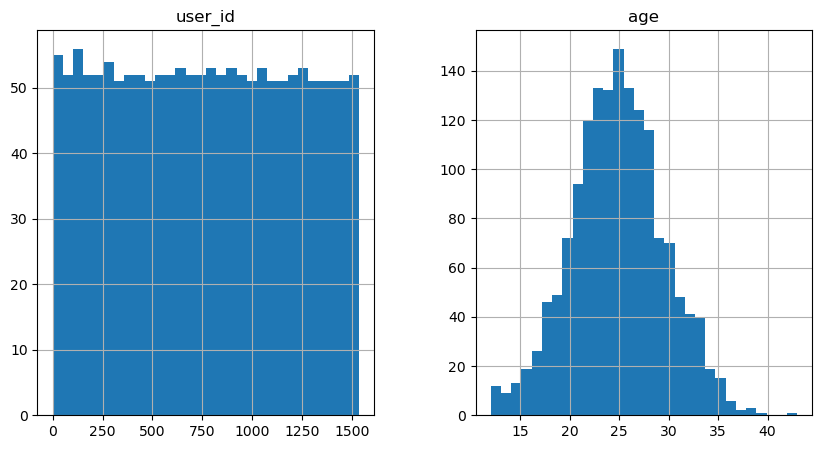

In [3]:
try: 
    users=pd.read_csv('users_go.csv', sep=',')
except:
    users=pd.read_csv('/datasets/users_go.csv', sep=',') # прочла csv-файл о пользователях
display(users.head())
display(users.info())
display(users.describe())
users.hist(figsize=(10, 5), bins=30);

Датасет 'user' о пользовалелях содержит 1565 срок. Пропуски и выбросы отсутствуют. 

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB


None

,user_id,distance,duration,date
count,18068.000000,18068.000000,18068.000000,18068
mean,842.869936,3070.659976,17.805011,2021-06-30 19:47:21.266327296
min,1.000000,0.855683,0.500000,2021-01-01 00:00:00
25%,487.000000,2543.226360,13.597563,2021-04-02 00:00:00
50%,889.000000,3133.609994,17.678395,2021-06-30 00:00:00
75%,1213.250000,3776.222735,21.724800,2021-09-28 00:00:00
max,1534.000000,7211.007745,40.823963,2021-12-30 00:00:00
std,434.734317,1116.831209,6.091051,NaN


None


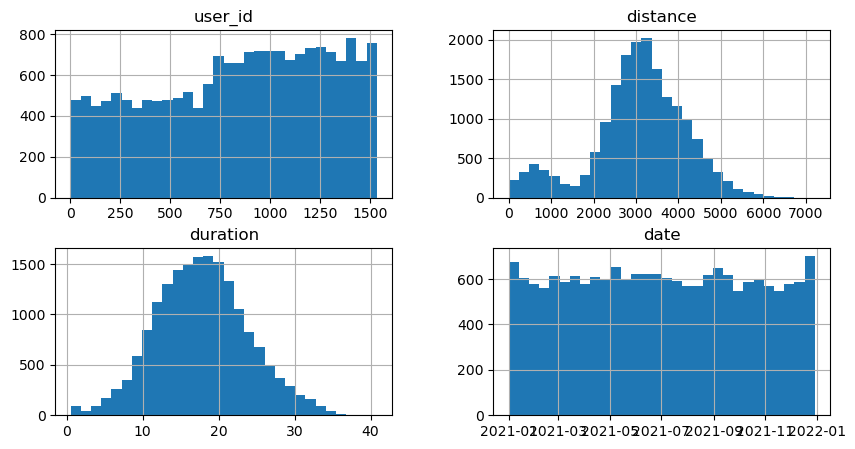

In [4]:
try: 
    rides=pd.read_csv('rides_go.csv', sep=',', parse_dates=['date'])
except:
    rides=pd.read_csv('/datasets/rides_go.csv', sep=',', parse_dates=['date']) # прочла csv-файл о поездках    
def met (rides):
    try:
        display(rides.head())
        display(rides.info())
        display(rides.describe())
    except:
        return 
result = met(rides)
print(result);
rides.hist(figsize=(10, 5), bins=30);

Датасет 'rides' о поездках содержит 18068 срок. Пропуски и выбросы отсутствуют. Некорректный тип данных столбца 'date' переведен в тип datetime64.

In [5]:
try: 
    subscriptions=pd.read_csv('subscriptions_go.csv', sep=',')
except:
    subscriptions=pd.read_csv('/datasets/subscriptions_go.csv', sep=',') # прочла csv-файл о подписках
def met (subscriptions):
    try:
        display(subscriptions.head())
        display(subscriptions.info())
        display(subscriptions.describe())
    except:
        return 
result = met(subscriptions)
print(result)

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 196.0+ bytes


None

,minute_price,start_ride_price,subscription_fee
count,2.000000,2.000000,2.000000
mean,7.000000,25.000000,99.500000
std,1.414214,35.355339,140.714249
min,6.000000,0.000000,0.000000
25%,6.500000,12.500000,49.750000
50%,7.000000,25.000000,99.500000
75%,7.500000,37.500000,149.250000
max,8.000000,50.000000,199.000000


None


Датасет 'subscriptions' о подписках содержит 2 сроки.

**Вывод:**

Открыты 3 файла с информацией о пользователях, их поездках и подписках. Пропуски и выбросы отсутствуют. Есть дубликаты и некорректный тип данных. 

## Шаг 2. Предобработка данных

### Проверить наличие пропущенных значений и дубликатов в датафреймах. Обработать их, если такие значения присутствуют

In [6]:
print(users.isna().sum()) # количество пропущенных значений для каждого столбца 
users.duplicated().sum() # число дубликатов 

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64


31

In [7]:
print(users['user_id'].unique()) # уникальные значения 'user_id'
print(users['age'].sort_values().unique()) # уникальные значения 'age'

[   1    2    3 ... 1532 1533 1534]
[12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35
 36 37 38 39 43]


In [8]:
duplicated_users = users[users.duplicated()] # дубликаты
duplicated_users

,user_id,name,age,city,subscription_type
1534,293,Агата,26,Краснодар,ultra
1535,16,Амалия,27,Краснодар,ultra
1536,909,Константин,20,Екатеринбург,free
1537,403,Полина,19,Сочи,ultra
1538,908,Рустам,30,Тюмень,free
1539,43,Стефания,22,Омск,ultra
1540,127,Павел,25,Пятигорск,ultra
1541,659,Злата,27,Ростов-на-Дону,ultra
1542,204,Руслан,30,Пятигорск,ultra
1543,153,Герман,23,Москва,ultra


In [9]:
users['city'].unique() # список городов в датасете

array(['Тюмень', 'Омск', 'Москва', 'Ростов-на-Дону', 'Краснодар',
       'Пятигорск', 'Екатеринбург', 'Сочи'], dtype=object)

In [10]:
# удаление дубликатов и сброс идексов
users=users.drop_duplicates().reset_index(drop=True)

In [11]:
# столбец 'subscription_type' в ДФ 'user' переведен в ти данных bool
users.loc[users['subscription_type'] == 'ultra', 'subscription_type'] = True # 'ultra'
users.loc[users['subscription_type'] == 'free', 'subscription_type'] = False # 'free'
users['subscription_type'] = users['subscription_type'].astype('bool')
print(users)

      user_id        name  age            city  subscription_type
0           1        Кира   22          Тюмень               True
1           2   Станислав   31            Омск               True
2           3     Алексей   20          Москва               True
3           4  Константин   26  Ростов-на-Дону               True
4           5       Адель   28            Омск               True
...       ...         ...  ...             ...                ...
1529     1530   Ростислав   29            Сочи              False
1530     1531      Никита   25       Пятигорск              False
1531     1532     Алексей   26          Тюмень              False
1532     1533      Степан   22       Краснодар              False
1533     1534     Альберт   25       Краснодар              False

[1534 rows x 5 columns]


In [12]:
print(rides.isna().sum()) # количество пропущенных значений для каждого столбца 
rides.duplicated().sum() # число дубликатов 

user_id     0
distance    0
duration    0
date        0
dtype: int64


0

In [13]:
rides['user_id'].unique() # уникальные значения 'user_id'

array([   1,    2,    3, ..., 1532, 1533, 1534], dtype=int64)

В 'rides' как и в ДФ 'user' кол-во id одинаковое с 1 до 1534. Следовательно, дальнейшее соединение датафреймов возможно по этому столбцу. 

***Вывод:***
Дубликаты удалены. Пропуски отсутствуют. Выяснили, что пользователей - 1534.

### Привести столбец date к типу даты pandas

In [14]:
# приведен столбец 'date' к типу даты pandas
rides['date'] = pd.to_datetime(rides['date'], format='%Y-%m-%d')

In [15]:
print(rides['date'].min())
print(rides['date'].max())

2021-01-01 00:00:00
2021-12-30 00:00:00


***Вывод:***
Предоставлена информация за период с 01.01.2021 по 30.12.2021

### Создать новый столбец с номером месяца на основе столбца date

In [16]:
# добавление столбца 'month'
rides['month']=rides['date'].dt.month
rides

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8
...,...,...,...,...,...
18063,1534,3781.098080,19.822962,2021-11-04,11
18064,1534,2840.423057,21.409799,2021-11-16,11
18065,1534,3826.185507,18.435051,2021-11-18,11
18066,1534,2902.308661,16.674362,2021-11-27,11


In [17]:
# столбец 'subscription_type' в ДФ 'subscriptions' переведен в тип данных bool
subscriptions.loc[subscriptions['subscription_type'] == 'ultra', 'subscription_type'] = True # 'ultra'
subscriptions.loc[subscriptions['subscription_type'] == 'free', 'subscription_type'] = False # 'free'
subscriptions['subscription_type'] = subscriptions['subscription_type'].astype('bool')
print(subscriptions)

   subscription_type  minute_price  start_ride_price  subscription_fee
0              False             8                50                 0
1               True             6                 0               199


**Вывод:**

В исследование данные о 1534 пользователях в 8 городах. Предоставлена информация за период с 01.01.2021 по 30.12.2021. В датафрейме 'user' удалены дубликаты. В датафрейм 'rides' добавлен новый столбец с номером месяца и столбец 'date' приведен к типу даты pandas. Столбцы 'subscription_type' переведены в тип данных bool. Расстояние и продолжительность сессии перевели в целочисленный тип данных. 

## Шаг 3. Исследовательский анализ данных

### Частота встречаемости городов

In [18]:
users['city'].value_counts()

city
Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: count, dtype: int64

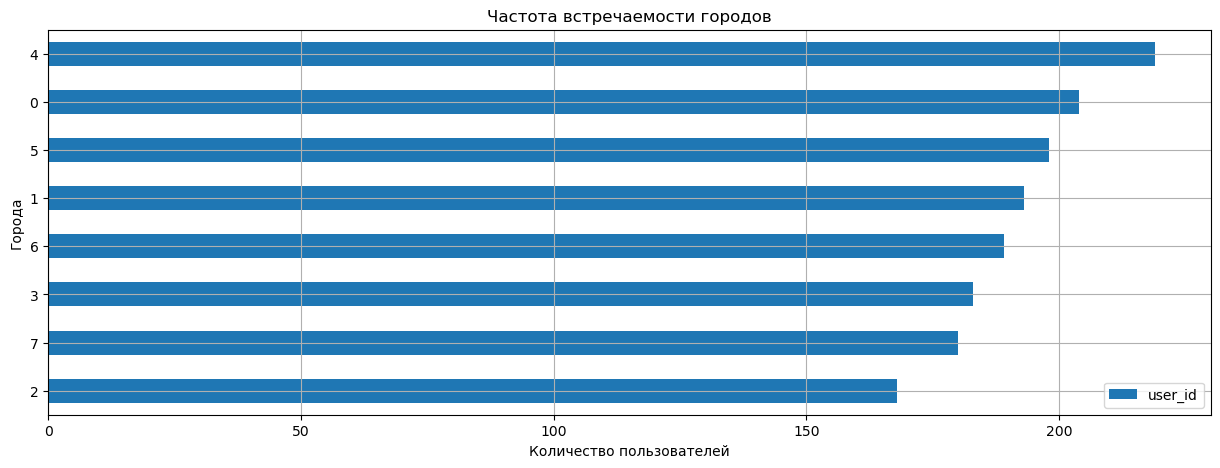

In [19]:
city = users.groupby('city')['user_id'].count().reset_index()
city.sort_values(by='user_id', ascending=True).plot(kind='barh', figsize = (15,5), grid=True)
plt.title('Частота встречаемости городов')
plt.xlabel('Количество пользователей')
plt.ylabel('Города')
plt.show()

Предоставлена информация о 8 городах. Больше всего пользователей в Пятигорске - 14%. 

### Соотношение пользователей с подпиской и без подписки

In [20]:
ultra=users.query('subscription_type == True')
print('Кол-во пользователей с подпиской', len(ultra))
rate_ultra = len(ultra)/len(users)
print('Пользователей с подпиской {:.0%}'.format(rate_ultra))

Кол-во пользователей с подпиской 699
Пользователей с подпиской 46%


In [21]:
free=users.query('subscription_type == False')
print('Кол-во пользователей без подписки', len(free))
rate_free = len(free)/len(users)
print('Пользователей без подписки {:.0%}'.format(rate_free))

Кол-во пользователей без подписки 835
Пользователей без подписки 54%


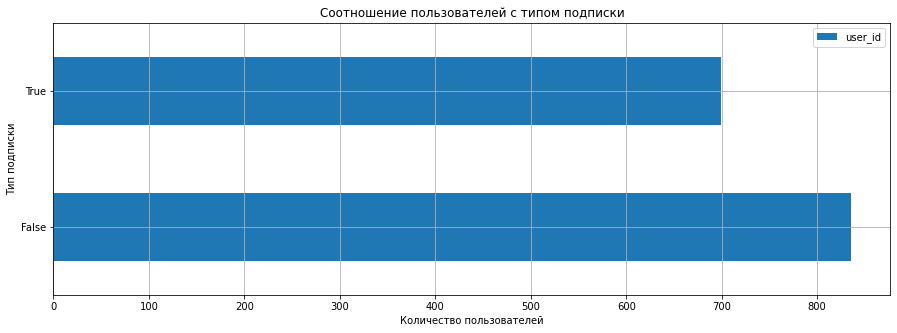

,subscription_type,user_id
0,False,835
1,True,699


In [22]:
users_ratio = users.groupby('subscription_type')['user_id'].count().reset_index()
users_ratio.plot(x = 'subscription_type', kind='barh', figsize = (15,5), grid = True )
plt.title('Соотношение пользователей с типом подписки')
plt.xlabel('Количество пользователей')
plt.ylabel('Тип подписки')
plt.show()
display(users_ratio)

Пользователей с подпиской 46%. Пользователей без подписки 54%.

### Возраст пользователей

In [23]:
users['age'].value_counts()

25    145
24    132
26    131
23    129
27    119
22    119
28    112
21     93
20     71
30     68
29     68
31     48
19     47
18     46
32     41
33     39
17     26
34     19
16     19
35     15
15     13
14      9
13      8
36      6
12      4
38      3
37      2
39      1
43      1
Name: age, dtype: int64

In [24]:
users['age'].describe() # описательная статистика возраста

count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

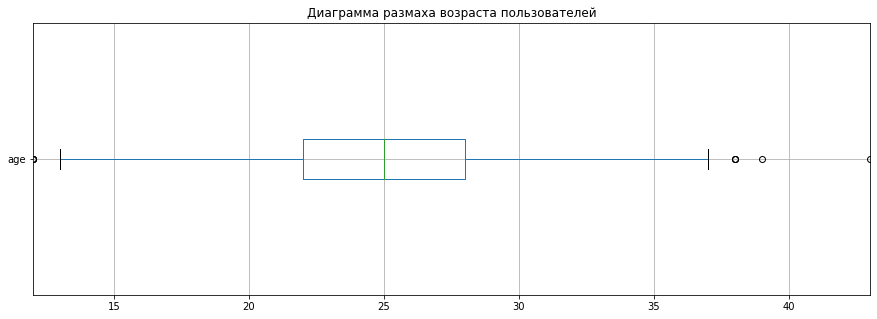

In [25]:
fig, ax = plt.subplots(figsize = (15,5))
ax = users[['age']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха возраста пользователей')
ax.set_xlim(12, 43);

Пределы нормальных значений от 13 до 37 лет.

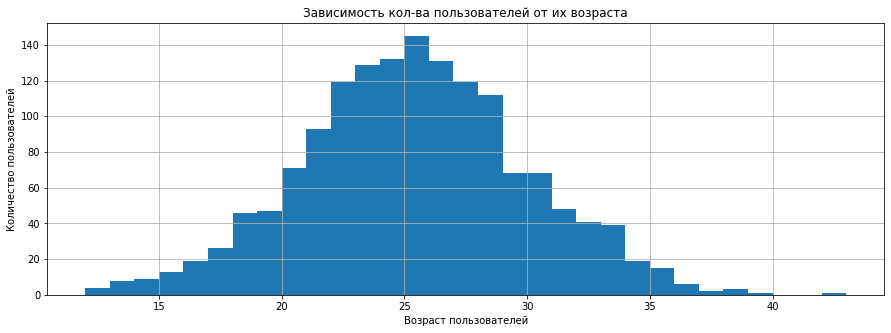

In [26]:
#гистограмма возраста пользователей
users['age'].hist(bins = 31, figsize = (15,5), range = (12, 43))
plt.ylabel('Количество пользователей')
plt.xlabel('Возраст пользователей')
plt.title('Зависимость кол-ва пользователей от их возраста');

In [27]:
ultra['age'].describe() # описательная статистика возраста пользователей с подпиской 

count    699.000000
mean      24.938484
std        4.739995
min       12.000000
25%       22.000000
50%       25.000000
75%       28.000000
max       38.000000
Name: age, dtype: float64

In [28]:
free['age'].describe() # описательная статистика возраста пользователей без подписки

count    835.000000
mean      24.874251
std        4.429815
min       12.000000
25%       22.000000
50%       25.000000
75%       28.000000
max       43.000000
Name: age, dtype: float64

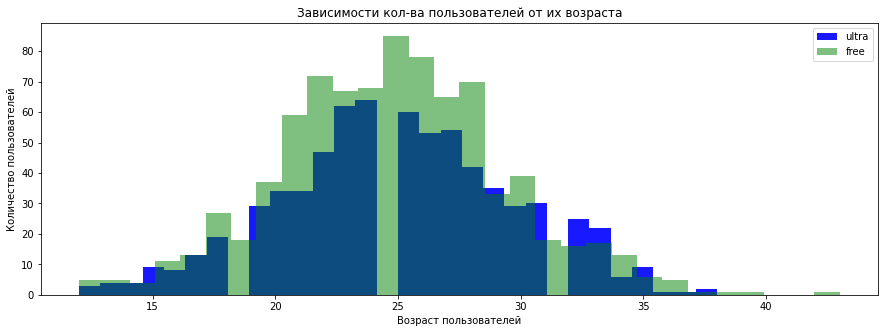

In [29]:
fig, ax = plt.subplots(figsize = (15,5))
plt.hist(ultra['age'], bins = 30, color = 'blue', alpha = 0.9, label = 'ultra')
plt.hist(free['age'], bins = 30, color = 'green', alpha = 0.5, label = 'free')
plt.legend()
plt.ylabel('Количество пользователей')
plt.xlabel('Возраст пользователей')
plt.title('Зависимости кол-ва пользователей от их возраста')
plt.show()

***Вывод:***
Распределение всей возрастной выборки имеет нормальное распределение. Максимальное количество пользователей в возрасте 25 лет. 

С подпиской максимальное количество пользователей в возрасте 23-24 года. Без подписки основной возраст - 25 лет. 

Максимальный возраст у пользователей с подпиской на 5 лет меньше - 38 лет, без подписки - 43 года. 

### Расстояние, которое пользователь преодолел за одну поездку

In [30]:
rides['distance'].describe() # описательная статистика расстояния 

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

Медиана от среднего отличается незначительно, т.е. есть выбросы, но они не сильно влияют на данные.

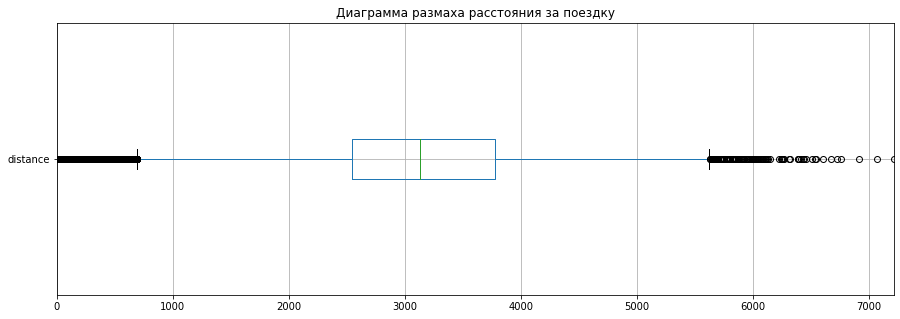

In [31]:
fig, ax = plt.subplots(figsize = (15,5))
ax = rides[['distance']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха расстояния за поездку')
ax.set_xlim(0, 7211);

Пределы нормальных значений от 700 до 5600 метров.

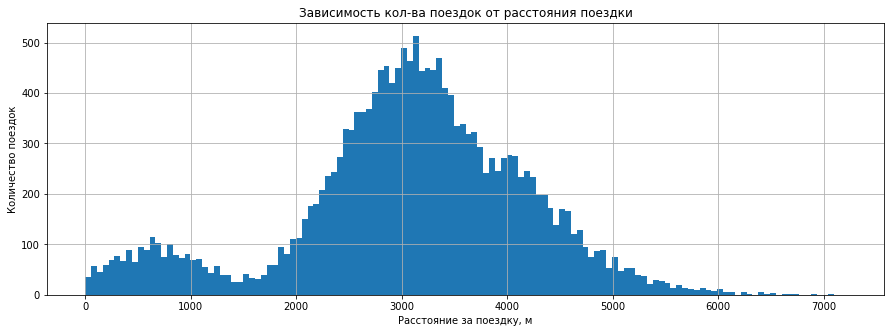

In [32]:
rides['distance'].hist(bins = 130, figsize = (15,5), range = (0,7211))
plt.ylabel('Количество поездок')
plt.xlabel('Расстояние за поездку, м')
plt.title('Зависимость кол-ва поездок от расстояния поездки');

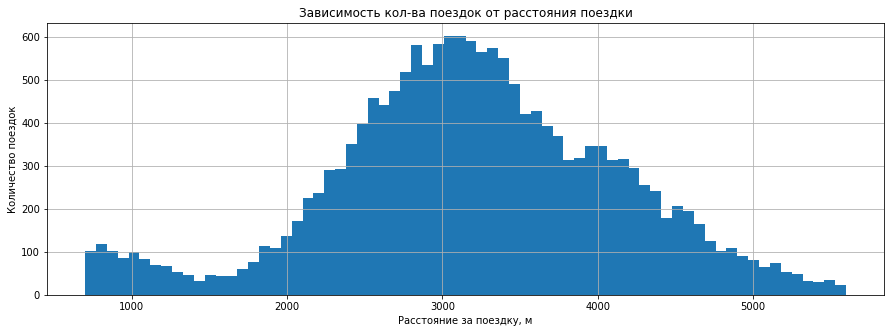

In [33]:
# гистограмма в пределах нормальных значений
rides['distance'].hist(bins = 70, figsize = (15,5), range = (700,5600))
plt.ylabel('Количество поездок')
plt.xlabel('Расстояние за поездку, м')
plt.title('Зависимость кол-ва поездок от расстояния поездки');

***Вывод:***
Самое большое количество поездок приходится на расстояние примерно 3150 метров. На графике наблюдаются 2 вершины - около 600 и около 3000 метров. Короткие поездки (до 1000 м) скорее всего совершают те, кому необходимо целенаправленно доехать до определенного места (например до метро, до магазина и т.д.). Длинные поездки (2500- 3500 м) для тех, кто гуляет, для кого это развлечение, как аренда коньков, велосипедов). 

### Продолжительность поездок

In [34]:
rides['duration'].describe()  # описательная статистика продолжительности поездки 

count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
25%         13.597563
50%         17.678395
75%         21.724800
max         40.823963
Name: duration, dtype: float64

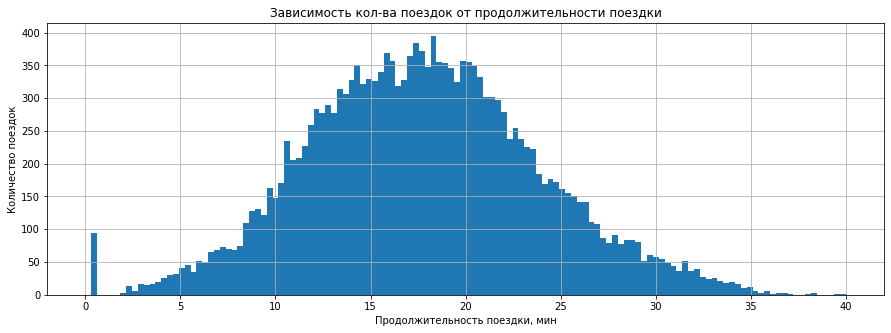

In [35]:
rides['duration'].hist(bins = 130, figsize = (15,5), range = (0,40))
plt.ylabel('Количество поездок')
plt.xlabel('Продолжительность поездки, мин')
plt.title('Зависимость кол-ва поездок от продолжительности поездки');

Наблюдается всплеск на 0.5 мин. Скорость 300 км/ч явно какая-то ошибка. Этот всплес аномалии. Возможно, сбоил модуль геопозиционирования.

In [36]:
rides=rides.query('duration != 0.5') # удалила аномалии 

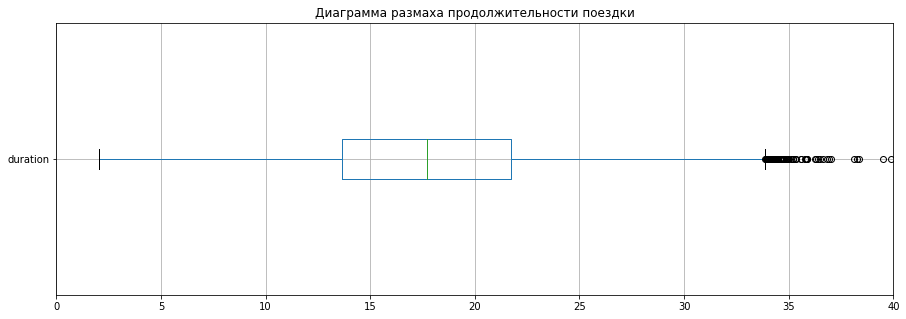

In [37]:
fig, ax = plt.subplots(figsize = (15,5))
ax = rides[['duration']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха продолжительности поездки')
ax.set_xlim(0, 40);

Пределы нормальных значений от 2 до 34 минут.

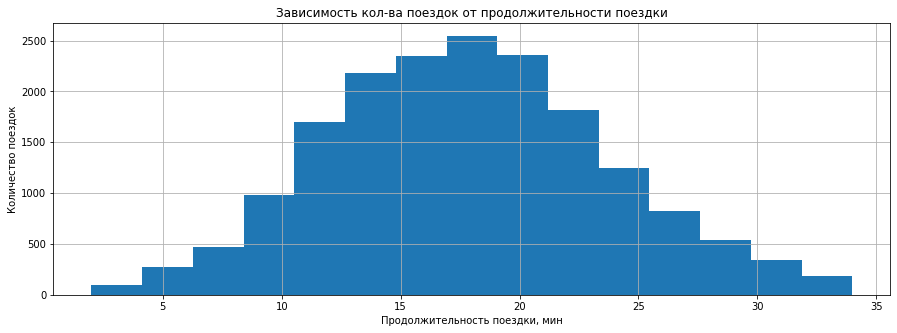

In [38]:
# гистограмма в пределах нормальных значений
rides['duration'].hist(bins = 15, figsize = (15,5), range = (2,34))
plt.ylabel('Количество поездок')
plt.xlabel('Продолжительность поездки, мин')
plt.title('Зависимость кол-ва поездок от продолжительности поездки');

Продолжительность поездок имеет нормальное распределение от 2 до 34 минут. Самая популярная сессия поездки - 17 минут. 

***Вывод:***
Предоставлена информация о 8 городах. Больше всего пользователей в Пятигорске - 14%, меньше всего в Москве - 11%. Пользователей с подпиской 46%. Пользователей без подписки 54%. Возраст пользователей - от 12 до 43 лет. Распределение всей возрастной выборки имеет нормальное распределение. Максимальное количество пользователей в возрасте 25 лет. Максимальный возраст пользователей с подпиской на 5 лет меньше (38 лет), чем у пользователей без подписки. Расстояние, которое пользователь преодолевает за поездку от 0 до 7211. Самое большое количество поездок приходится на расстояние примерно 3150. На графике наблюдаются 2 вершины - около 600 м и около 3000 м, т.е. наблюдаются коротие и длинные поездки. Продолжительность поездок до 40 минут имеет нормальное распределение. Были выявлены и удалены аномалии около 0. Самая популярная сессия поездки - 17 минут. 

## Шаг 4. Объединение данных

### Объединить данных в один датафрейм

In [39]:
total=users.merge(rides, on='user_id', how='outer').merge(subscriptions, on='subscription_type', how='outer')
total

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,True,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,True,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,True,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,True,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,True,4028.687306,26.265803,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
17968,1534,Альберт,25,Краснодар,False,3781.098080,19.822962,2021-11-04,11,8,50,0
17969,1534,Альберт,25,Краснодар,False,2840.423057,21.409799,2021-11-16,11,8,50,0
17970,1534,Альберт,25,Краснодар,False,3826.185507,18.435051,2021-11-18,11,8,50,0
17971,1534,Альберт,25,Краснодар,False,2902.308661,16.674362,2021-11-27,11,8,50,0


In [40]:
total.isna().sum() # количество пропущенных значений для каждого столбца 

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
distance             0
duration             0
date                 0
month                0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

In [41]:
print(len(total['user_id'].unique())) # кол-во пользователей
total['user_id'].count() # кол-во поездок

1534


17973

***Вывод:***
После слияния таблиц в одну все данные сохранились: пропуски отсутствуют, кол-во пользователей и кол-во поездок соответсвуют изначальным данным.

### Создать два датафрейма с/без подписки

In [42]:
total_ultra = total.query('subscription_type == True')
print('Кол-во пользователей с подпиской', len(total_ultra))
rate_total_ultra = len(total_ultra)/len(total)
print('Пользователей с подпиской {:.0%}'.format(rate_total_ultra))

Кол-во пользователей с подпиской 6500
Пользователей с подпиской 36%


In [43]:
print(total_ultra.isna().sum())
display(total_ultra.info())

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
distance             0
duration             0
date                 0
month                0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 6500 entries, 0 to 6499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            6500 non-null   int64         
 1   name               6500 non-null   object        
 2   age                6500 non-null   int64         
 3   city               6500 non-null   object        
 4   subscription_type  6500 non-null   bool          
 5   distance           6500 non-null   float64       
 6   duration           6500 non-null   float64       
 7   date               6500 non-null   datetime64[ns]
 8   month              6500 non-null   int64         

None

In [44]:
total_free = total.query('subscription_type == False')
print('Кол-во пользователей без подписки', len(total_free))
rate_total_free = len(total_free)/len(total)
print('Пользователей без подписки {:.0%}'.format(rate_total_free))

Кол-во пользователей без подписки 11473
Пользователей без подписки 64%


In [45]:
print(total_free.isna().sum())
display(total_free.info())

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
distance             0
duration             0
date                 0
month                0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 11473 entries, 6500 to 17972
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            11473 non-null  int64         
 1   name               11473 non-null  object        
 2   age                11473 non-null  int64         
 3   city               11473 non-null  object        
 4   subscription_type  11473 non-null  bool          
 5   distance           11473 non-null  float64       
 6   duration           11473 non-null  float64       
 7   date               11473 non-null  datetime64[ns]
 8   month              11473 non-null  int64    

None

***Вывод:***
После разделения датафрейма total два датафрейма с/без подписки выяснили, что пользователей без подписки 64%, с подпиской - 36%. Пропуски отсутствуют.

### Визуализировать информацию о расстоянии и времени поездок для пользователей обеих категорий

In [46]:
total_ultra['distance'].describe().round(2) # описательная статистика расстояния для пользователей с подпиской 

count    6500.00
mean     3115.45
std       836.90
min       244.21
25%      2785.44
50%      3148.64
75%      3560.57
max      5699.77
Name: distance, dtype: float64

Значения медианны и среднего практически одинаковы. 

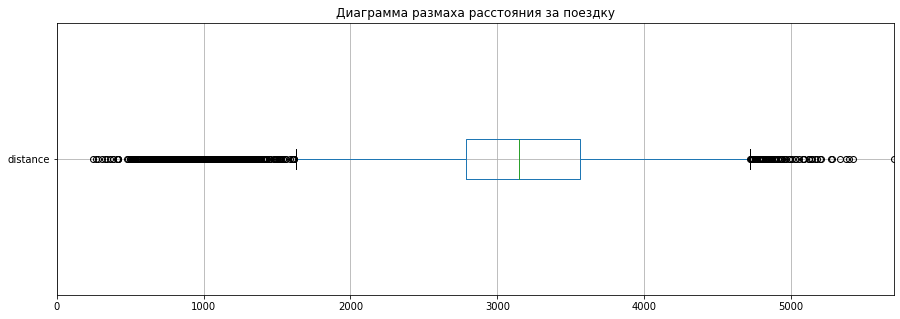

In [47]:
fig, ax = plt.subplots(figsize = (15,5))
ax = total_ultra[['distance']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха расстояния за поездку')
ax.set_xlim(0, 5699);

In [48]:
total_free['distance'].describe() # описательная статистика расстояния для пользователей без подписки 

count    11473.000000
mean      3028.374239
std       1235.541051
min          0.855683
25%       2360.878149
50%       3102.083025
75%       3883.979311
max       7066.003772
Name: distance, dtype: float64

Присутсвуют незначительные выбросы. Стандартное отклонение стало больше - график шире. 

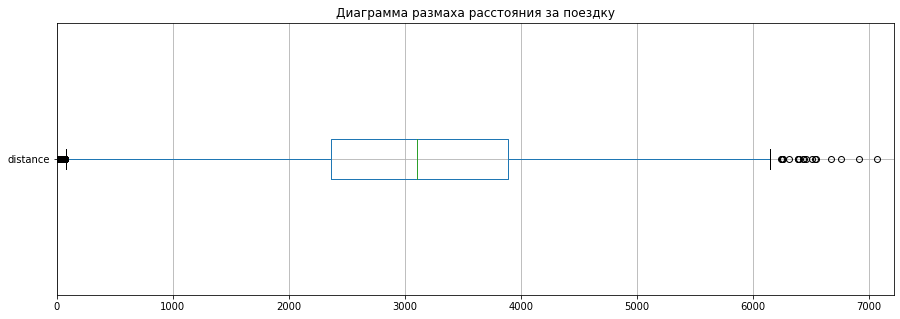

In [49]:
fig, ax = plt.subplots(figsize = (15,5))
ax = total_free[['distance']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха расстояния за поездку')
ax.set_xlim(0, 7211);

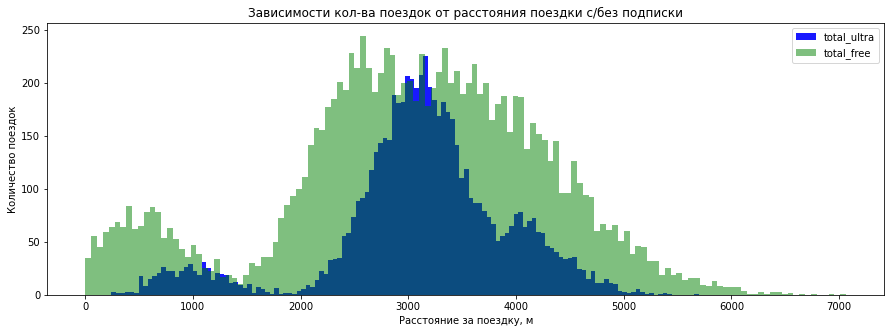

In [50]:
fig, ax = plt.subplots(figsize = (15,5))
plt.hist(total_ultra['distance'], bins = 130, color = 'blue', alpha = 0.9, label = 'total_ultra')
plt.hist(total_free['distance'], bins = 130, color = 'green', alpha = 0.5, label = 'total_free')
plt.legend()
plt.ylabel('Количество поездок')
plt.xlabel('Расстояние за поездку, м')
plt.title('Зависимости кол-ва поездок от расстояния поездки с/без подписки')
plt.show()

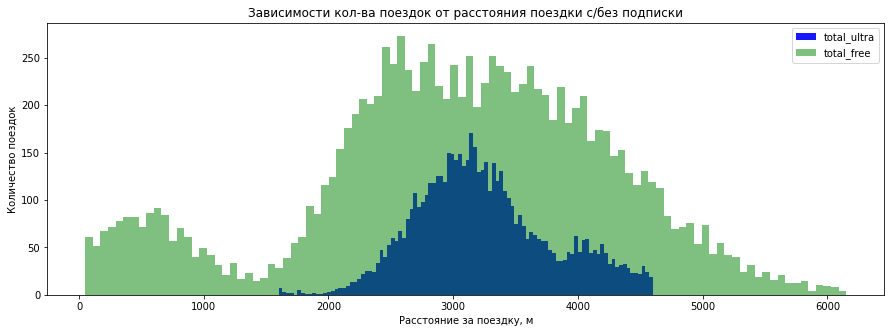

In [51]:
# гистограммы в пределах нормальных значений
fig, ax = plt.subplots(figsize = (15,5))
plt.hist(total_ultra['distance'], bins = 100, color = 'blue', alpha = 0.9, label = 'total_ultra', range=(1600,4600))
plt.hist(total_free['distance'], bins = 100, color = 'green', alpha = 0.5, label = 'total_free', range=(50,6150))
plt.legend()
plt.ylabel('Количество поездок')
plt.xlabel('Расстояние за поездку, м')
plt.title('Зависимости кол-ва поездок от расстояния поездки с/без подписки')
plt.show()

In [52]:
# доля пользователей на короткие заезды 
shorts_total = len(total.query('distance <= 1000'))/len(total)
print('Пользователи на короткие заезды {:.2%}'.format(shorts_total))

# доля пользователей на долгие заезды 
long_total = len(total.query('2500 <= distance <= 3500'))/len(total)
print('Пользователи на долгие заезды {:.2%}'.format(long_total))

Пользователи на короткие заезды 7.63%
Пользователи на долгие заезды 42.78%


In [53]:
# доля пользователей с подпиской на короткие заезды 
shorts_total_ultra = len(total_ultra.query('distance <= 1000'))/len(total) 
print('Пользователи с подпиской на короткие заезды {:.2%}'.format(shorts_total_ultra))

# доля пользователей с подпиской на долгие заезды 
long_total_ultra = len(total_ultra.query('2500 <= distance <= 3500'))/len(total) 
print('Пользователи с подпиской на долгие заезды {:.2%}'.format(long_total_ultra))

Пользователи с подпиской на короткие заезды 1.44%
Пользователи с подпиской на долгие заезды 21.42%


In [54]:
# доля пользователей без подписки на короткие заезды 
shorts_total_free = len(total_free.query('distance <= 1000'))/len(total)
print('Пользователи без подписки на короткие заезды {:.2%}'.format(shorts_total_free))

# доля пользователей без подписки на долгие заезды 
long_total_free = len(total_ultra.query('2500 <= distance <= 3500'))/len(total) 
print('Пользователи без подписки на долгие заезды {:.2%}'.format(long_total_free))

Пользователи без подписки на короткие заезды 6.19%
Пользователи без подписки на долгие заезды 21.42%


In [55]:
total_ultra['duration'] # описательная статистика времени поездки для пользователей с подпиской 

0       25.599769
1       15.816871
2        6.232113
3       18.511000
4       26.265803
          ...    
6495    24.671163
6496    15.892886
6497    14.389525
6498    15.839579
6499    25.217345
Name: duration, Length: 6500, dtype: float64

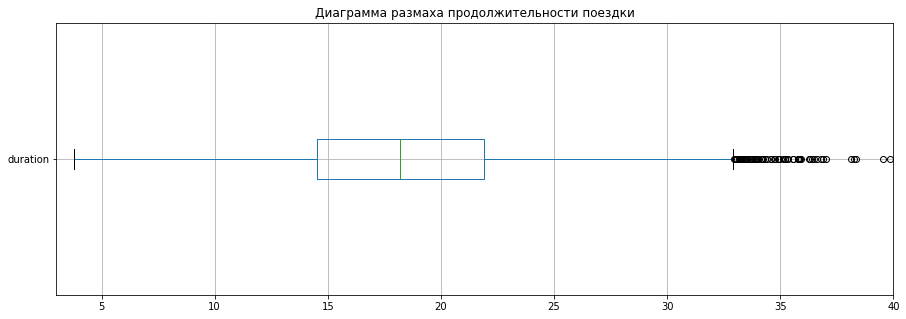

In [56]:
fig, ax = plt.subplots(figsize = (15,5))
ax = total_ultra[['duration']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха продолжительности поездки')
ax.set_xlim(3, 40);

In [57]:
total_free['duration'].describe() # описательная статистика времени поездки для пользователей без подписки 

count    11473.000000
mean        17.530771
std          6.162609
min          2.035632
25%         13.085688
50%         17.383807
75%         21.638038
max         34.948498
Name: duration, dtype: float64

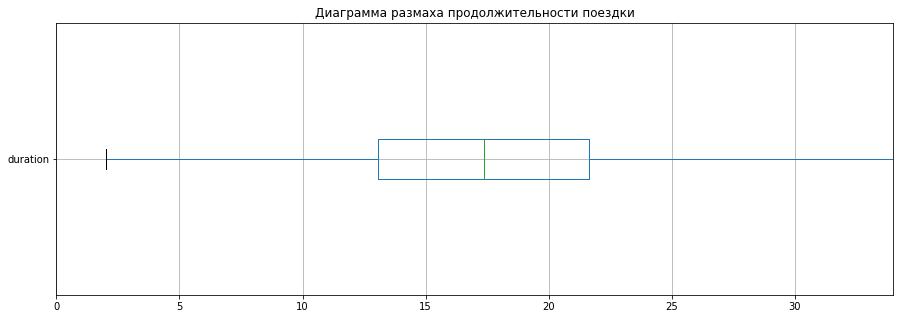

In [58]:
fig, ax = plt.subplots(figsize = (15,5))
ax = total_free[['duration']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха продолжительности поездки')
ax.set_xlim(0, 34);

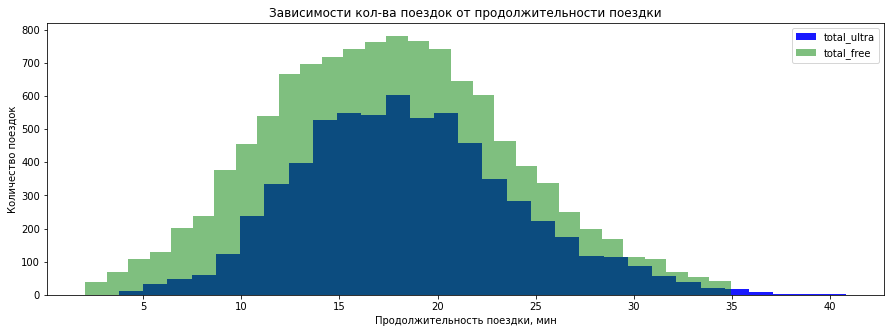

In [59]:
fig, ax = plt.subplots(figsize = (15,5))
plt.hist(total_ultra['duration'], bins = 30, color = 'blue', alpha = 0.9, label = 'total_ultra')
plt.hist(total_free['duration'], bins = 30, color = 'green', alpha = 0.5, label = 'total_free')
plt.legend()
plt.ylabel('Количество поездок')
plt.xlabel('Продолжительность поездки, мин')
plt.title('Зависимости кол-ва поездок от продолжительности поездки')
plt.show()

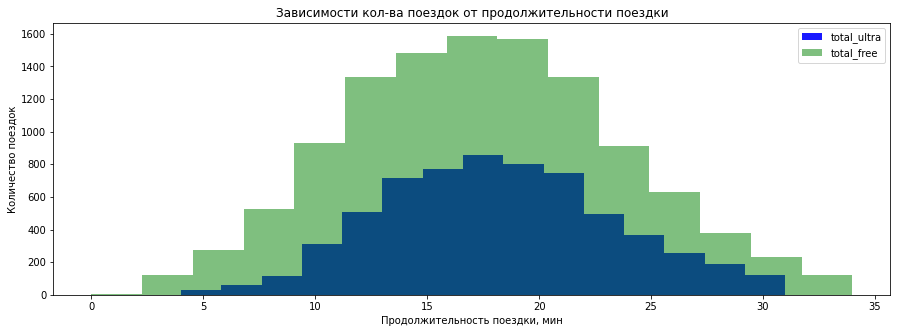

In [60]:
# гистограммы в пределах нормальных значений
fig, ax = plt.subplots(figsize = (15,5))
plt.hist(total_ultra['duration'], bins = 15, color = 'blue', alpha = 0.9, label = 'total_ultra', range = (4,31))
plt.hist(total_free['duration'], bins = 15, color = 'green', alpha = 0.5, label = 'total_free', range = (0,34))
plt.legend()
plt.ylabel('Количество поездок')
plt.xlabel('Продолжительность поездки, мин')
plt.title('Зависимости кол-ва поездок от продолжительности поездки')
plt.show()

##### ***Вывод:***
Пропущенные значения в объединенной таблице total - отсутствуют. Кол-во пользователей 1534, кол-во поездок 18068, как и в отдельных таблицах. Пользователей с подпиской в total 36%, а без подписки - 64%, следовательно кол-во поездок без подписки больше.

С подпиской: расстояние от 244 до 5699 м, значения медианны и среднего практически одинаковы, самое большое кол-во поездок на расстояние 2400-4300, пик на 3200 м. Время поездки от 4 до 40 минут, значения медианны и среднего одинаковы, частые сессии от 9 до 26 минут.

Без подписки:  расстояние до 7211 м, чаще всего поезки до 1000 метров и 1800-5200, пик на 2500 м. Время поездки максимально до 34 минут, значения медианны и среднего практически одинаковы, частые сессии от 6 до 26 минут. Большая доля коротких поездок (до 1000 м) приходится на пользователей без подписки 6.19%, а вот долгие поездки (2500-3500 м) эквивалентны.

Продолжительность поездок без использования подписки на 6 минут меньше, чем при подписке, а вот расстояние, наоборот, больше и многообразнее(шире), хотя среднее значение преодоленного расстояния без подписки чуть меньше, чем среднее значение расстояния с подпиской. Для коротких поездок составляет 1.44%.
Зависимости количества поездок от их продолжительности для обеих категорий распределены нормально. Пик количества поездок приходится на 17-18 минут.

## Шаг 5. Подсчёт выручки

### Создать датафрейм с агрегированными данными о поездках - суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц

In [61]:
# округляем продолжительность поезки до следующего целого числа
total['duration'] = np.ceil(total['duration'])
total['duration'] = total['duration'].astype('int')
# округляем расстояние до следующего целого числа
total['distance'] = np.ceil(total['distance'])
total['distance'] = total['distance'].astype('int')

In [62]:
# применение определенных функций к определенным столбцам
func = {'distance': ['count', 'sum'], 'duration': ['sum'], 'minute_price': ['min'],
        'start_ride_price': ['min'], 'subscription_fee': ['min']} 
# датафрейм с агрегированными данными о поездках
total_sum = total.pivot_table(index = ['user_id', 'month'], values = ['distance', 'duration','minute_price',
                                                                      'start_ride_price', 'subscription_fee'], aggfunc=(func))
# приведение "двухэтажных" названий столбцов к "одноэтажному"
total_sum.columns = ['_'.join(col) for col in total_sum.columns]
total_sum

distance_count  distance_sum  duration_sum  minute_price_min  \
user_id month                                                                 
1       1                   2          7028            42                 6   
        4                   1           755             7                 6   
        8                   2          6724            46                 6   
        10                  2          5811            32                 6   
        11                  3          7005            56                 6   
...                       ...           ...           ...               ...   
1534    6                   2          3411            26                 8   
        8                   2          7623            48                 8   
        9                   1          4929            23                 8   
        11                  4         13353            78                 8   
        12                  1          2372            16                 8   

               start_ride_price_min  subscription_fee_min  
user_id month                                              
1       1                         0                   199  
        4                         0                   199  
        8                         0                   199  
        10                        0                   199  
        11                        0                   199  
...                             ...                   ...  
1534    6                        50                     0  
        8                        50                     0  
        9                        50                     0  
        11                       50                     0  
        12                       50                     0  

[11300 rows x 6 columns]

In [63]:
total_sum.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 11300 entries, (1, 1) to (1534, 12)
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   distance_count        11300 non-null  int64
 1   distance_sum          11300 non-null  int64
 2   duration_sum          11300 non-null  int64
 3   minute_price_min      11300 non-null  int64
 4   start_ride_price_min  11300 non-null  int64
 5   subscription_fee_min  11300 non-null  int64
dtypes: int64(6)
memory usage: 575.0 KB


***Вывод:***
создали датафрейм с агрегированными данными о поездках - total_sum, показывающий суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц. Пропуски в total_sum отсутствуют.

### Создать столбец с помесячной выручкой

In [64]:
def income(total_sum):
    price_start = total_sum['start_ride_price_min']
    count = total_sum['distance_count']
    price_minute = total_sum['minute_price_min']
    duration = total_sum['duration_sum']
    subscription = total_sum['subscription_fee_min']
    income = price_start*count+price_minute*duration+subscription
    return (income)
total_sum['income'] = total_sum.apply(income, axis=1)
total_sum['income'] = total_sum['income'].astype('int')
total_sum

distance_count  distance_sum  duration_sum  minute_price_min  \
user_id month                                                                 
1       1                   2          7028            42                 6   
        4                   1           755             7                 6   
        8                   2          6724            46                 6   
        10                  2          5811            32                 6   
        11                  3          7005            56                 6   
...                       ...           ...           ...               ...   
1534    6                   2          3411            26                 8   
        8                   2          7623            48                 8   
        9                   1          4929            23                 8   
        11                  4         13353            78                 8   
        12                  1          2372            16                 8   

               start_ride_price_min  subscription_fee_min  income  
user_id month                                                      
1       1                         0                   199     451  
        4                         0                   199     241  
        8                         0                   199     475  
        10                        0                   199     391  
        11                        0                   199     535  
...                             ...                   ...     ...  
1534    6                        50                     0     308  
        8                        50                     0     484  
        9                        50                     0     234  
        11                       50                     0     824  
        12                       50                     0     178  

[11300 rows x 7 columns]

In [66]:
total_sum.loc[total_sum['income']==total_sum['income'].min()] # минимальное значение выручки 

,,distance_count,distance_sum,duration_sum,minute_price_min,start_ride_price_min,subscription_fee_min,income
user_id,month,,,,,,,
768,2,1,274,3,8,50,0,74
880,3,1,12,3,8,50,0,74
910,2,1,127,3,8,50,0,74
1053,9,1,392,3,8,50,0,74
1103,2,1,148,3,8,50,0,74
1138,2,1,296,3,8,50,0,74
1139,11,1,170,3,8,50,0,74
1363,7,1,265,3,8,50,0,74
1395,2,1,394,3,8,50,0,74


Пользователи с минимальной суммой за поездку 74 р.

In [67]:
total_sum.loc[total_sum['income']==total_sum['income'].max()] # максимальное значение выручки 

,,distance_count,distance_sum,duration_sum,minute_price_min,start_ride_price_min,subscription_fee_min,income
user_id,month,,,,,,,
1471,1,6,23102,143,8,50,0,1444


Пользователь с максимальной суммой за поездку 1444 р.

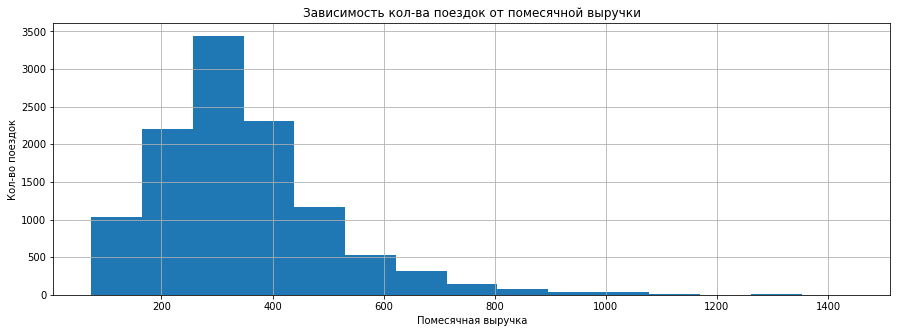

In [68]:
# гистограмма помесячной выручки 
total_sum['income'].plot(kind='hist', bins=15, grid=True, figsize = (15, 5))
plt.ylabel('Кол-во поездок')
plt.xlabel('Помесячная выручка')
plt.title('Зависимость кол-ва поездок от помесячной выручки');

Большинство пользователей тратят в месяц по 300 рублей.

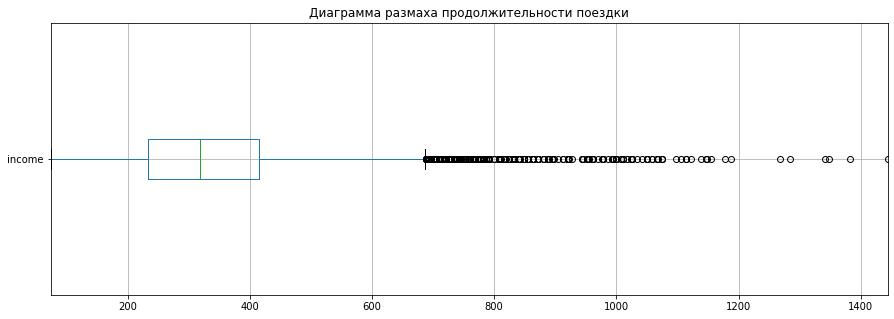

In [69]:
fig, ax = plt.subplots(figsize = (15,5))
ax = total_sum[['income']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха продолжительности поездки')
ax.set_xlim(74, 1444);

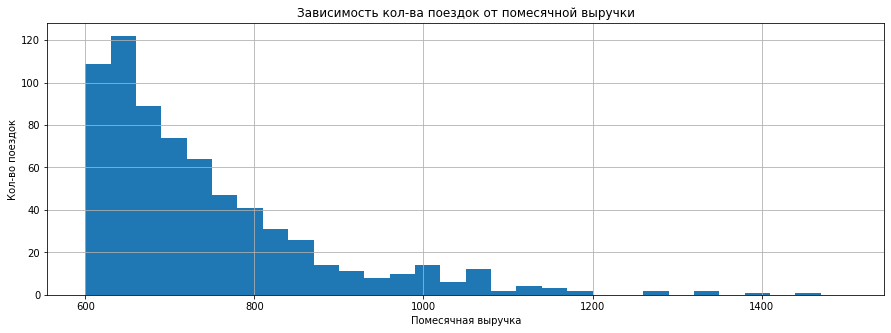

In [70]:
# гистограмма помесячной выручки (хвост)
total_sum['income'].plot(kind='hist', bins=30, grid=True, figsize = (15, 5), range=(600,1500))
plt.ylabel('Кол-во поездок')
plt.xlabel('Помесячная выручка')
plt.title('Зависимость кол-ва поездок от помесячной выручки');

Единицы, кто тратит более 1100 рублей в месяц.

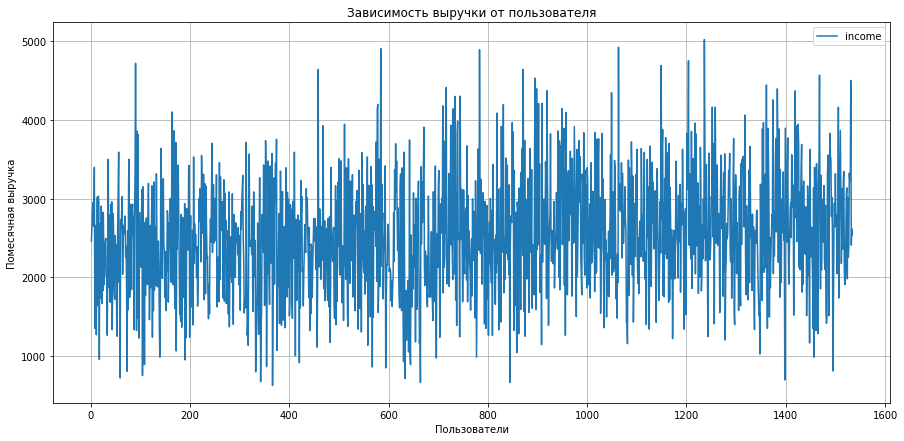

In [71]:
total_sum.pivot_table(index='user_id', values='income', aggfunc='sum').plot(grid=True, figsize=(15, 7))
plt.title('Зависимость выручки от пользователя')
plt.ylabel('Помесячная выручка')
plt.xlabel('Пользователи');

В среднем каждый пользователь принес 2500-3000 тысячи рублей за год. Минимально начиная с 500 рублей до 5000 тысяч рублей.

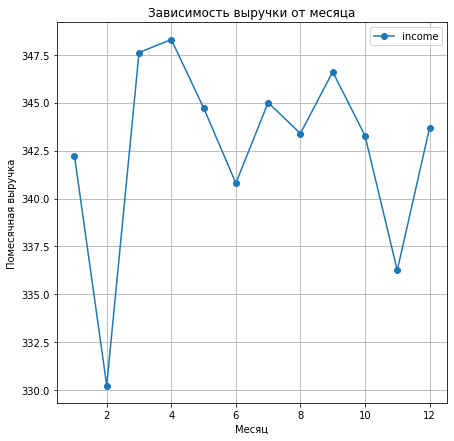

In [72]:
total_sum.pivot_table(index='month', values='income').plot(grid=True, style='o-', figsize=(7, 7))
plt.title('Зависимость выручки от месяца')
plt.ylabel('Помесячная выручка')
plt.xlabel('Месяц');

In [73]:
# показатели выручки пользователей с подпиской
total_sum_ultra = total_sum.query('subscription_fee_min == 199')
print('Суммарная годовая выручка с подпиской', total_sum_ultra['income'].sum())
print('Доля выручки с подпиской', (total_sum_ultra['income'].sum()/total_sum['income'].sum()*100).round(2))
print('Минимальная выручка в месяц', total_sum_ultra['income'].min())
print('Максимальная выручка в месяц', total_sum_ultra['income'].max())
print('Среднемесячная выручка', (total_sum_ultra['income'].mean()).round(0))

Суммарная годовая выручка с подпиской 1644537
Доля выручки с подпиской 42.46
Минимальная выручка в месяц 223
Максимальная выручка в месяц 955
Среднемесячная выручка 363.0


In [74]:
# показатели выручки пользователей без подписки
total_sum_free = total_sum.query('subscription_fee_min == 0')
print('Суммарная годовая выручка без подписки', total_sum_free['income'].sum())
print('Доля выручки с подпиской', (total_sum_free['income'].sum()/total_sum['income'].sum()*100).round(2))
print('Минимальная выручка в месяц', total_sum_free['income'].min())
print('Максимальная выручка в месяц', total_sum_free['income'].max())
print('Среднемесячная выручка в месяц', (total_sum_free['income'].mean()).round(0))

Суммарная годовая выручка без подписки 2228594
Доля выручки с подпиской 57.54
Минимальная выручка в месяц 74
Максимальная выручка в месяц 1444
Среднемесячная выручка в месяц 329.0


***Вывод:***
Помесячная выручка включает в себя: стоимость старта поездки * количество поездок + стоимость одной минуты поездки * общая продолжительность всех поездок в минутах + стоимость подписки в месяц.
Большое кол-во пользователей тратят около 300 рублей в месяц. Крайне единичные случаи тратят более 1100 рублей в месяц. В среднем каждый пользователь принес 2500-3000 тысячи рублей за год. Минимально начиная с 500 рублей до 5000 тысяч рублей за год.
Самый прибыльные месяца для компании март-апрель и сентябрь, а менее прибыльные оказались февраль, июнь и ноябрь. 

С подпиской: суммарная годовая выручка 1.6 млн рублей - 42.46% от общей выручки, а среднемесячная выручка 363 рублей.

Без подписки: суммарная годовая выручка 2.2 млн рублей - 57.54% от общей выручки, а среднемесячная выручка 329 рублей.

## Шаг 6. Проверка гипотез

Продакт-менеджеры сервиса хотят увеличить количество пользователей с подпиской. Для этого они будут проводить различные акции, но сначала нужно выяснить несколько важных моментов.

### Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании. Проверить гипотезу

Нулевая и альтернативная гипотезы:

Н0: Средние продолжительности поездок с подпиской и без подписки равны

Н1: Средняя продолжительность поездок с подпиской больше, чем средняя продолжительность поездок без подписки

In [75]:
# задаём уровень значимости
alpha = 0.05

# проводим ttest для двух выборок, в качестве альтернативной используем одностороннюю гипотезу «больше»
results = st.ttest_ind(total_ultra['duration'], total_free['duration'], equal_var=False, alternative='greater')

print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-value: 1.6162210195311063e-29
Отвергаем нулевую гипотезу


In [76]:
# Приведены два датасета: сумма покупок, совершённых за месяц посетителями ...

sample_1 = [3071, 3636, 3454, 3151, 2185, 3259, 1727, 2263, 2015,
2582, 4815, 633, 3186, 887, 2028, 3589, 2564, 1422, 1785,
3180, 1770, 2716, 2546, 1848, 4644, 3134, 475, 2686,
1838, 3352]
sample_2 = [1211, 1228, 2157, 3699, 600, 1898, 1688, 1420, 5048, 3007,
509, 3777, 5583, 3949, 121, 1674, 4300, 1338, 3066,
3562, 1010, 2311, 462, 863, 2021, 528, 1849, 255,
1740, 2596]
alpha = .05 # критический уровень статистической значимости
# если p-value окажется меньше него - отвергнем гипотезу
results = st.ttest_ind(
sample_1,
sample_2)
print('p-значение:', results.pvalue)
if (results.pvalue < alpha):
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")

p-значение: 0.1912450522572209
Не получилось отвергнуть нулевую гипотезу


Проверим - выведем на экран среднии значения продолжительности поездок c подпиской и без подписки. 

In [77]:
print('Средняя продолжительность поездок c подпиской:', total_ultra['duration'].mean().round(2))
print('Средняя продолжительность поездок без подписки:', total_free['duration'].mean().round(2))

Средняя продолжительность поездок c подпиской: 18.54
Средняя продолжительность поездок без подписки: 17.53


In [78]:
total_ultra['duration'].describe()

count    6500.000000
mean       18.541985
std         5.572048
min         3.760353
25%        14.524654
50%        18.178153
75%        21.884129
max        40.823963
Name: duration, dtype: float64

In [79]:
total_free['duration'].describe()

count    11473.000000
mean        17.530771
std          6.162609
min          2.035632
25%         13.085688
50%         17.383807
75%         21.638038
max         34.948498
Name: duration, dtype: float64

***Вывод:***
Сами среднии значения продолжительности поездок c подпиской и без подписки на первый взгляд отличаются незначительно, но статистический тест говорит нам, что это большое разлиичие между между значениями. Полученное значение p-value меньше заданного уровня значимости, поэтому нулевую гипотезу отвегаем в пользу альтернативной. Следовательно, можно сказать, что пользователи с подпиской тратят больше времени на поездки. Среднее и медианное значения продолжительности поездок у пользователй с подпиской больше, чем без подписки, хотя пользователей с подпиской меньше. Если затрачено больше времени на поездки, значит больше прибыли для компании. Следовательно, можно утверждать, что пользователи с подпиской выгоднее для компании.

### Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? Проверить гипотезу

Нулевая и альтернативная гипотезы:

Н0: Среднее расстояние с подпиской равна 3130 метров

Н1: Среднее расстояние с подпиской более 3130 метров

In [80]:
# задаём уровень значимости
alpha = 0.05

# оптимальное расстояние
optim_value = 3130

# проводим ttest для одной выборки, в качестве альтернативной используем одностороннюю гипотезу «больше»
results = st.ttest_1samp(total_ultra['distance'], optim_value, alternative='greater')

print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-value: 0.9195368847849785
Не получилось отвергнуть нулевую гипотезу


В данном случае p-value достаточно велико - выше уровня значимости. 

In [81]:
total_ultra['distance'].mean()

3115.4453880370247

In [82]:
total_free['distance'].mean()

3028.3742391936416

***Вывод:***
Не получилось отвергнуть гипотезу. Так как для значений меньше 3130 метров гипотеза не сформулирована, то нулевая гипотеза для них тоже не отвергается. Следовательно, среднее расстояние поездок с подписки равно или меньше 3130 метров, что явно хорошо для бизнеса, так как износ самокатов оптимальный. А это в свою очередь значит, что ремонтные работы соответсвуют регламенту, минимальный риск поломок сверх нормы, а значит прибыль стабильная. 

### Проверить гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки

Выгоднее ли для компании пользователи с подпиской? Сравним среднии значения помесячной выручки c подпиской и без подписки.

Нулевая и альтернативная гипотезы:

Н0: Средняя помесячная выручка с подпиской и без подписки равны

Н1: Средняя помесячная выручка с подпиской больше, чем средняя помесячная выручка без подписки

In [83]:
print(total_sum['subscription_fee_min'].value_counts())

rate_ultra = total_sum_ultra['subscription_fee_min'].count()/ total_sum['subscription_fee_min'].count()*100
print('Доля пользователей с подпиской:', rate_ultra.round(0))

rate_free = total_sum_free['subscription_fee_min'].count()/ total_sum['subscription_fee_min'].count()*100
print('Доля пользователей без подписки:', rate_free.round(0))

0      6767
199    4533
Name: subscription_fee_min, dtype: int64
Доля пользователей с подпиской: 40.0
Доля пользователей без подписки: 60.0


In [84]:
# задаём уровень значимости
alpha = 0.05

# проводим ttest для двух выборок, в качестве альтернативной используем одностороннюю гипотезу «больше»
results = st.ttest_ind(total_sum_ultra['income'], total_sum_free['income'], equal_var=False, alternative='greater')

print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-value: 2.4970242872858465e-38
Отвергаем нулевую гипотезу


В данном случае p-value крайне маленькая - близка к 0. Среднии значения выручек с\без подписки значимо отличаются друг от друга.

In [85]:
print('Средняя помесячная выручка c подпиской:', total_sum_ultra['income'].mean())
print('Средняя помесячная выручка без подписки:', total_sum_free['income'].mean())

Средняя помесячная выручка c подпиской: 362.7921906022502
Средняя помесячная выручка без подписки: 329.3326437121324


***Вывод:***
Полученное значение p-value меньше заданного уровня значимости, поэтому нулевую гипотезу отвегаем в пользу альтернативной. Следовательно, можно сказать, что помесячная выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки, а ведь как выяснили ранее, пользователей с подпиской меньше. То есть удельно пользователи с подпиской приносят больше денег компании, чем пользователи без подписки, а также вдолгую пользователи с подпиской могут быть выгоднее, так как просто могут забыть про подписки. Следовательно, можно утверждать, что пользователи с подпиской выгоднее для компании.

### Представить ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест понадобился бы для проверки этой гипотезы?

Исспользуем тест scipy.stats.ttest_rel(before, after), в случае если, зарегистрированные обращения от одних и тех же пользователей и порядок объектов одинаковый, т.е. выборки парные. Будем проверять, равны ли средние совокупности до и после изменения.

Нулевая и альтернативная гипотезы:

Н0: Средние значения кол-ва обращений до и после обновления сервиса равны

Н1: Средние значения кол-ва обращений до и после обновления сервиса не равны

In [86]:
before = [3, 2, 3, 7, 3, 10, 6, 6, 3, 6, 
          4, 5, 10, 5, 7, 4, 5, 9, 4, 9, 
          6, 4, 6, 7, 6, 2, 4, 5, 5, 6]

after = [1, 2, 2, 3, 6, 1, 6, 4, 3, 1, 
         2, 2, 8, 3, 3, 1, 1, 4, 2, 7, 
         5, 1, 4, 2, 2, 1, 1, 1, 2, 3]

alpha = 0.01 # уровень статистической значимости

results = st.ttest_rel(before, after)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу о равенстве средних')
else:
    print('Не получилось отвергнуть нулевую гипотезу о равенстве средних')

p-значение: 2.412092201430269e-07
Отвергаем нулевую гипотезу о равенстве средних


p-value крайне маленькая - близка к 0. Отвергаем нулевую гипотезу о равенстве средних значений количества обращений до и после обновления. Значит, можно сделать вывод, что кол-во обращений после обновления изменилось. А вот в какую сторону, в большую или меньшую, найдем, посчтав срредние. Так как гипотеза двустороняя только по p-value судить нельзя.

In [87]:
print('Среднее до:', pd.Series(before).mean())
print('Среднее после:', pd.Series(after).mean())

Среднее до: 5.4
Среднее после: 2.8


***Вывод:***
После обновления количество обращений в техподдержку стало меньше.

## Шаг 7. Распределения

### Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж. Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают 10 % пользователей. Выясните, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5 %. Подберите параметры распределения, описывающего эту ситуацию, постройте график распределения и сформулируйте ответ на вопрос о количестве промокодов.

Подписку можно продлить или же нет - это биномиальный эксперимент. Необходимо минимум 100 успехов - те, кто продлит подписку.
Продливают подписку 10%. Следовательно начать рассылку можно с 1000 промокодов.

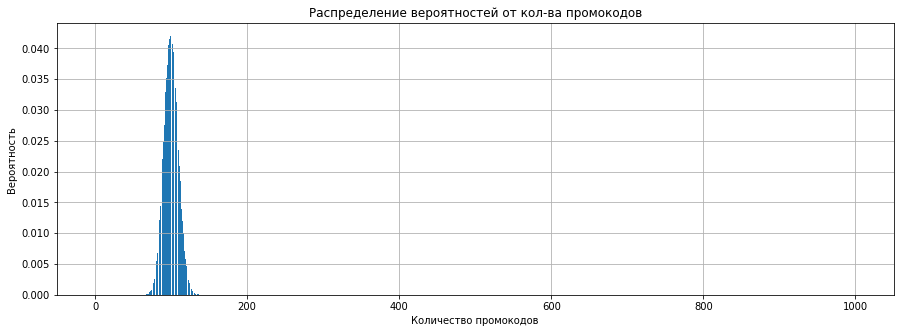

In [88]:
p = 0.1 # вероятность продлить подписку
n = 1000 # кол-вол промокодов 

distr = [] # список distr, в котором будете хранить значения распределения

for k in range(0, n + 1):
    choose = factorial(n) / (factorial(k) * factorial(n - k))
    prob = choose * p**k * (1 - p)**(n - k) # распределение вероятностей
    distr.append(prob)
fig, ax = plt.subplots(figsize = (15,5))
plt.bar(range(0, n + 1), distr) #  гистограмма распределения вероятностей
plt.ylabel('Вероятность')
plt.xlabel('Количество промокодов')
plt.title('Распределение вероятностей от кол-ва промокодов')
plt.grid()
plt.show()

100 - наиболее вероятный результат. Но и до 100 - велика вероятность неудач - около 10%. 

In [89]:
for n in range (1000,1500):
    if binom.cdf(100, n, p) < 0.05:
        print("Минимальное число промокодов:", n)

Минимальное число промокодов: 1172
Минимальное число промокодов: 1173
Минимальное число промокодов: 1174
Минимальное число промокодов: 1175
Минимальное число промокодов: 1176
Минимальное число промокодов: 1177
Минимальное число промокодов: 1178
Минимальное число промокодов: 1179
Минимальное число промокодов: 1180
Минимальное число промокодов: 1181
Минимальное число промокодов: 1182
Минимальное число промокодов: 1183
Минимальное число промокодов: 1184
Минимальное число промокодов: 1185
Минимальное число промокодов: 1186
Минимальное число промокодов: 1187
Минимальное число промокодов: 1188
Минимальное число промокодов: 1189
Минимальное число промокодов: 1190
Минимальное число промокодов: 1191
Минимальное число промокодов: 1192
Минимальное число промокодов: 1193
Минимальное число промокодов: 1194
Минимальное число промокодов: 1195
Минимальное число промокодов: 1196
Минимальное число промокодов: 1197
Минимальное число промокодов: 1198
Минимальное число промокодов: 1199
Минимальное число пр

1172 - минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5 %.

### Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40 % получивших клиентов. Отдел планирует разослать 1 млн уведомлений. С помощью аппроксимации постройте примерный график распределения и оцените вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.

In [90]:
# задаём параметры биномиального распределения
n = 1000000
p = 0.4

# зададим мат.ожидание и ст.отклонение нормального распределения равными
# мат.ожиданию и ст.отклонению биномиального распределения
mu = n * p
sigma = sqrt(n * p * (1 - p))

# задаём нормальное распределение
distr = st.norm(mu, sigma) 

# считаем вероятность хвоста слева от 399500 тыс. пользователейтысячи
result = distr.cdf(399500)
print(result)


0.15371708296369768


При рассылки 1 млн. push-уведомлений вероятность того, что откроют их не более 399,5 тыс. пользователей - 15%. Другими словами, вероятность того, что уведомления откроют менее 399 тыс. пользователей - 15%, если разослать 1 млн. уведомлений, которые открывают пользователи с вероятностью 40%. Неплохо, но лучше разослать больше уведомлений.   

## Шаг 8. Написать общий вывод

В целях увеличения роста бизнеса сервиса аренды самокатов GoFast, компания намеренна провести акции, чтобы увеличить количество пользователей с подпиской. Для этого были проанализированы данные о 1534 пользователях из 8 городов, а также об их поездках за 2021 год и проведены проверки некоторых гипотез. 

На этапе предобработки данных были достигнуты консистентности данных трех файлов: удалены дубликаты и изменены типи данных по некоторым столбцам. 

В результате исследования высинили, что большое количество пользователей находятся в Пятигорске - 14%, а меньше всего в Москве – 11%. Их возраст варьируется от 12 до 43, преобладают пользователи 25 лет. Пользователей с подпиской 46%, их возраст до 38. Пользователей без подписки 54%, их максимальный возраст выше на 5 лет пользователей с подпиской.

Расстояние, которое пользователь проезжает за поездку - до 7 км и имеет два пика на около 600 и 3000 м - короткие и долгие поездки. Большая доля коротких поездок (до 1000 м) приходится на пользователей без подписки 6.19% из 7.63% всего, а вот долгие поездки (2500-3500 м) эквивалентны.Продолжительность поездок до 40 минут имеет нормальное распределение. Самая популярная сессия поездки - 17 минут. Были обнаружены и удалены аномалии, равные 1 минуте поездке.  

Данные трех файлов были объединены для получения полномасштабного анализа всех поездок. После слияния датафреймов пользователей с подпиской стало 36%, без подписки - 64%, следовательно кол-во поездок без подписки больше на 20%.

Продолжительность поездок без использования подписки на 6 минут меньше, чем при подписке, а вот расстояние, наоборот, больше и многообразнее(шире), хотя среднее значение преодоленного расстояния без подписки чуть меньше, чем среднее значение расстояния с подпиской. Зависимости количества поездок от их продолжительности для обеих категорий распределены нормально. Пик количества поездок приходится на 17-18 минут.
Большое кол-во пользователей тратят около 300 рублей в месяц. Крайне единичные случаи тратят более 1100 рублей в месяц. В среднем каждый пользователь принес 2500-3000 тысячи рублей за год. Минимально начиная с 500 рублей до 5000 тысяч рублей за год. Самый прибыльные месяца для компании март-апрель и сентябрь, а менее прибыльные оказались февраль, июнь и ноябрь.

В ходе проверки гипотез установили важные инсайты:
- пользователи с подпиской тратят больше времени на поездки. Если затрачено больше времени на поездки, значит больше прибыли для компании. Следовательно, можно утверждать, что пользователи с подпиской выгоднее для компании.
- среднее расстояние поездок с подписки больше, чем среднее расстояние поездок без подписки, и оно равно или меньше 3130 метров, т.е. износ самокат оптимальный, что явно хорошо для бизнеса. Так как ремонтные работы соответсвуют регламенту, минимальный риск поломок сверх нормы, а значит прибыль стабильная.
- суммарная годовая выручка от пользователей с подпиской ниже на 15%, хотя помесячная выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки, а ведь как выяснили ранее, пользователей с подпиской меньше. То есть удельно пользователи с подпиской приносят больше денег компании, чем пользователи без подписки, а также вдолгую пользователи с подпиской могут быть выгоднее, так как просто могут забыть про подписки. Следовательно, можно утверждать, что пользователи с подпиской выгоднее для компании. 

Данные выводы можно использовать для проведения акции, чтобы увеличить количество пользователей с подпиской.

Таким образом, даже не смотря на меньшее кол-во пользователей с подпиской, они делают выручку больше в сравнении без подписки, то есть активнее пользуются услугами сервиса GoFast.
Данная информация предоставляет возможность создать интересные предложения для пользователей и новых клиентов, чтобы сделать подписку более привлекательной и использовать сервис активнее и продолжительнее.

Рекомендуется подумать, сколько минимально пользователей с подпиской должно быть, чтобы они приносили в общей массе больше денег, чем без нее.

Данные выводы можно использовать для проведения акции, чтобы увеличить количество пользователей с подпиской.